In [6]:
from RT_utils import run_RT, plot_rt_summary, load_dat_colormap
import matplotlib.pyplot as plt
import os
import numpy as np

In [20]:
custom_cmap = load_dat_colormap(r"D:\FROG_RT_Xuyang\color_maps\Wh_rainbow.dat")

result, eng = run_RT(
    file_dir=r"Z:\Data\2026_03_10_FROG\Scanning_FROG_10Hz_20260311",
    search_str=r"frog_38230fs2_0002_20260311_034610.tiff",
    matlab_code_dir=r"Z:\Code\Experimental_Analysis\FROG\Frog_Automated",
    max_iter=300,
    plot_iter=1000,
    temporal_calibration=2.0,
    spectral_calibration=0.4614,
    background=5,
    central_wavelength=400,
    sz=256,
    width=70,
    verbose=False
)

print("Selected file:", result["selected_file"])
print("Final G:", result["final_G"])
print("Best G :", result["best_G"])

plot_rt_summary(
    result,
    save_dir=r"D:\FROG_RT_Xuyang\results",
    filename="test_run_001.png"
)

eng.quit()

Selected file: frog_38230fs2_0002_20260311_034610.tiff
Final G: 0.012526850658378505
Best G : 0.012526850658378505


In [21]:
#for dazzler value from 38030 to 38380 fs2 in steps of 50 fs2, find the file and run the RT algorithm, then plot the summary of the results.

def find_scanning_frog_files(dazzler_second_scanning):
    path=r"Z:\Data\2026_03_10_FROG\Scanning_FROG_10Hz_20260311"
    files = []
    for file in os.listdir(path):
        if file.endswith(".tiff") and str(dazzler_second_scanning) in file:
            files.append(os.path.join(path, file))
            break
    return files

In [27]:

for dazzler_value in range(38030, 38380 + 1, 50):
    files = find_scanning_frog_files(dazzler_value)
    if not files:
        print(f"No file found for dazzler value: {dazzler_value}")
        continue
    print(f"Found file for dazzler value {dazzler_value}: {files[0]}")
    result, eng = run_RT(
        file_dir=r"Z:\Data\2026_03_10_FROG\Scanning_FROG_10Hz_20260311",
        search_str=files[0],
        matlab_code_dir=r"Z:\Code\Experimental_Analysis\FROG\Frog_Automated",
        max_iter=500,
        plot_iter=500,
        temporal_calibration=2.0,
        spectral_calibration=0.4614,
        background=5,
        central_wavelength=400,#386.78,
        sz=256,
        width=70,
        verbose=False
    )
    #save the results in a npz file in the results folder with the name scanning_frog_{dazzler_value}.npz
    np.savez(
        os.path.join(r"D:\FROG_RT_Xuyang\results\Scanning_FROG", f"scanning_frog_{dazzler_value}.npz"),
        result=result
    )
    plot_rt_summary(
        result,
        save_dir=r"D:\FROG_RT_Xuyang\results\Scanning_FROG",
        filename=f"scanning_frog_{dazzler_value}.png"
    )
    eng.quit()

Found file for dazzler value 38030: Z:\Data\2026_03_10_FROG\Scanning_FROG_10Hz_20260311\frog_38030fs2_0013_20260311_053537.tiff
Found file for dazzler value 38080: Z:\Data\2026_03_10_FROG\Scanning_FROG_10Hz_20260311\frog_38080fs2_0009_20260311_044125.tiff
Found file for dazzler value 38130: Z:\Data\2026_03_10_FROG\Scanning_FROG_10Hz_20260311\frog_38130fs2_0008_20260311_043410.tiff
Found file for dazzler value 38180: Z:\Data\2026_03_10_FROG\Scanning_FROG_10Hz_20260311\frog_38180fs2_0007_20260311_042657.tiff
Found file for dazzler value 38230: Z:\Data\2026_03_10_FROG\Scanning_FROG_10Hz_20260311\frog_38230fs2_0002_20260311_034610.tiff
Found file for dazzler value 38280: Z:\Data\2026_03_10_FROG\Scanning_FROG_10Hz_20260311\frog_38280fs2_0003_20260311_035417.tiff
Found file for dazzler value 38330: Z:\Data\2026_03_10_FROG\Scanning_FROG_10Hz_20260311\frog_38330fs2_0004_20260311_040140.tiff
Found file for dazzler value 38380: Z:\Data\2026_03_10_FROG\Scanning_FROG_10Hz_20260311\frog_38380fs2_00

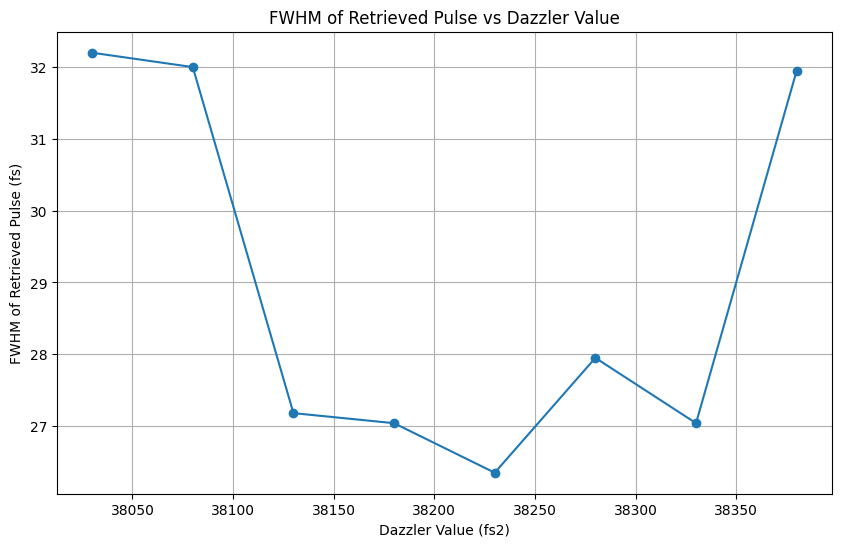

In [30]:
#plot FWHM of the retrieved pulse as a function of the dazzler value, using the results saved in the npz files.

dazzler_values = []
#fwhm_values = []
fwhm_values=[32.20,32.00,27.18,27.04,26.35,27.95,27.04,31.95]
for dazzler_value in range(38030, 38380 + 1, 50):
    npz_file = os.path.join(r"D:\FROG_RT_Xuyang\results\Scanning_FROG", f"scanning_frog_{dazzler_value}.npz")
    if not os.path.exists(npz_file):
        print(f"No result file found for dazzler value: {dazzler_value}")
        continue
    data = np.load(npz_file, allow_pickle=True)
    result = data["result"].item()
    #fwhm = result["FWHMt"]
    dazzler_values.append(dazzler_value)
    #fwhm_values.append(fwhm)
plt.figure(figsize=(10, 6))
plt.plot(dazzler_values, fwhm_values, marker='o') 
plt.title("FWHM of Retrieved Pulse vs Dazzler Value")
plt.xlabel("Dazzler Value (fs2)")
plt.ylabel("FWHM of Retrieved Pulse (fs)")
plt.grid()
plt.savefig(r"D:\FROG_RT_Xuyang\results\Scanning_FROG\fwhm_vs_dazzler_value.png")
plt.show()

In [12]:
#Now do the same for SSFROG data.
import tifffile as tiff
from PIL import Image
background_file=r"Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ\Background_Gain28\BKFLY613__24492756__20260311_044808760_0077.tiff"
background_array = tiff.imread(background_file)

#find n files with highest count
def find_ssfrog_files(path_ssfrog, dazzler_second_scanning, n_files):
    folder_path=None
    for folder in os.listdir(path_ssfrog):
        if str(dazzler_second_scanning) in folder:
            folder_path = os.path.join(path_ssfrog, folder)
            break

    ssfrog_files=[]
    if folder_path:
        for file in os.listdir(folder_path):
            if "BKFLY613" in file:
                ssfrog_files.append(os.path.join(folder_path, file))
    
    #for each file in ssfrog_files, read the tiff file and find the max value in the array
    #find the top n files with the highest max value, and return them
    #if the max value is 65535, it means the image is saturated, and we should not use it for analysis
    max_values = []
    for file in ssfrog_files:
        img = Image.open(file)
        arr = np.array(img)
        max_values.append(np.max(arr))
    #sort the files by max value in descending order
    sorted_files = [file for _, file in sorted(zip(max_values, ssfrog_files), key=lambda pair: pair[0], reverse=True)]
    #filter out the files with max value 65535
    sorted_files = [file for file in sorted_files if np.max(np.array(Image.open(file))) < 65535]
    return sorted_files[:n_files]

path_ssfrog=r"Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ"
dazzler_second_ssfrog=38530
ssfrog_files= find_ssfrog_files(path_ssfrog,dazzler_second_ssfrog,30)
print("number of SSFROG files found for dazzler second", dazzler_second_ssfrog, ":", len(ssfrog_files))

number of SSFROG files found for dazzler second 38530 : 20


Size of SSFROG file: (1024, 1024)
Max value of SSFROG file: 31296.0


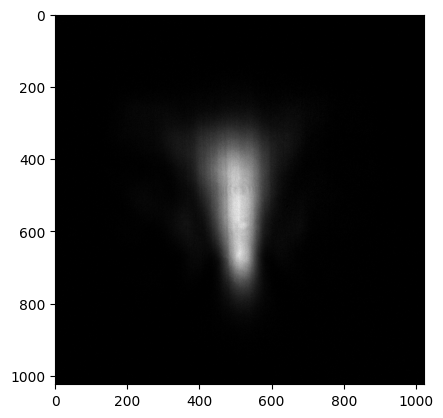

In [13]:
#use the first file for analysis
ssfrog_file= ssfrog_files[1]
img_ssfrog = Image.open(ssfrog_file)
arr_ssfrog = np.array(img_ssfrog)
background_array = tiff.imread(background_file).astype(np.float32)
arr_ssfrog = arr_ssfrog.astype(np.float32)
array_background_removed = arr_ssfrog - background_array
array_background_removed = np.clip(array_background_removed, 1, None)
arr_ssfrog=array_background_removed
#make the x axis 1024, crop the right boundary if necessary
offset = (arr_ssfrog.shape[1] - 1024)/2
arr_ssfrog = arr_ssfrog[:, int(offset):int(offset)+1024].T
#print size and max value of the ssfrog_file
print("Size of SSFROG file:", arr_ssfrog.shape)
print("Max value of SSFROG file:", np.max(arr_ssfrog))
#show it
plt.imshow(arr_ssfrog, cmap='gray')

Saved input TIFF: D:\FROG_RT_Xuyang\Results\SSFROG\calibration\test_001.tiff
Selected file: test_001.tiff
Runtime (no plotting): 30.577 s
Final G: 0.00918703
Best G : 0.00918703
Selected file: test_001.tiff
Final G: 0.009187028508959503
Best G : 0.009187028347626122


(<Figure size 1800x1000 with 11 Axes>,
 array([[<Axes: title={'center': 'Original Trace'}>,
         <Axes: title={'center': 'Reconstructed Trace'}>,
         <Axes: title={'center': 'Difference'}>],
        [<Axes: title={'center': 'Temporal | FWHM=27.71 fs'}>,
         <Axes: title={'center': 'Spectral | FWHM=29.67 nm'}>,
         <Axes: title={'center': 'G vs Iter | Final=0.009187'}>]],
       dtype=object))

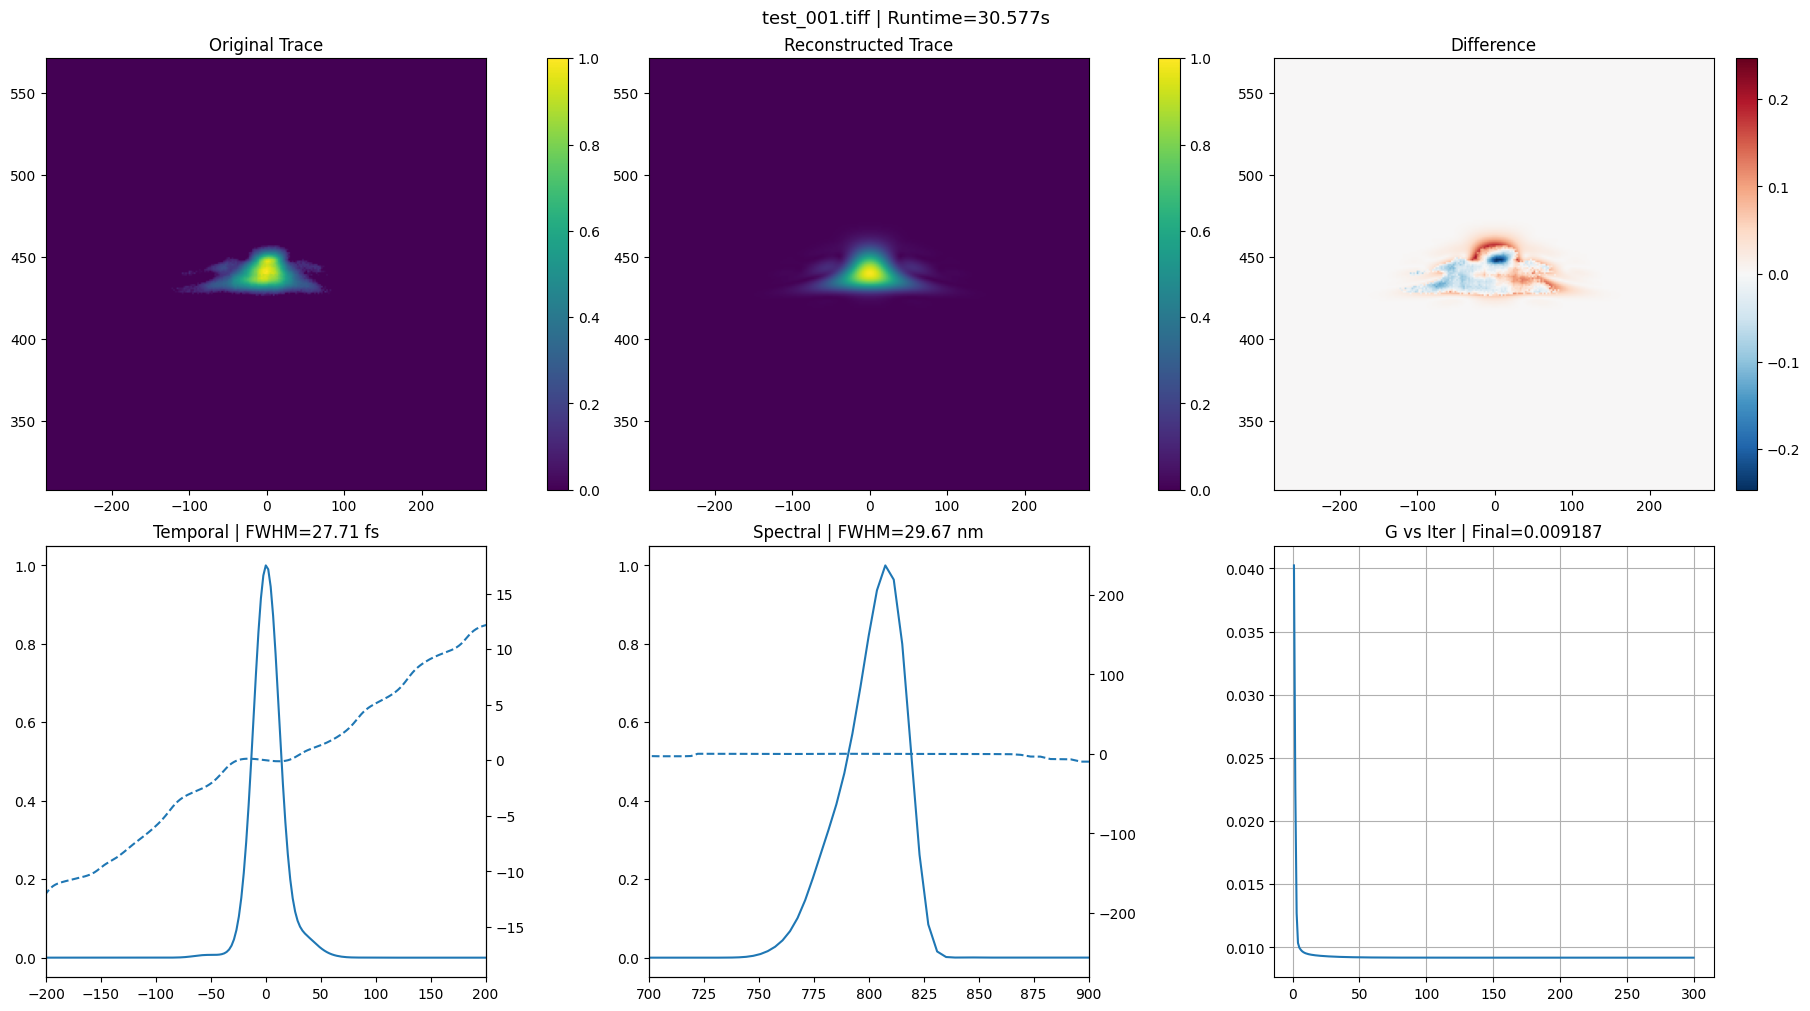

In [14]:
#perform RT on the selected SSFROG file, and plot the summary of the results.
result, eng = run_RT(
    input_array=arr_ssfrog,
    input_name="test_001",
    input_save_dir=r"D:\FROG_RT_Xuyang\Results\SSFROG\calibration",
    matlab_code_dir=r"Z:\Code\Experimental_Analysis\FROG\Frog_Automated",
    max_iter=300,
    plot_iter=1000,
    temporal_calibration=0.387225,
    spectral_calibration=0.043919,
    background=5,
    central_wavelength=400,
    sz=256,
    width=70,
    verbose=True
)
#print and directly plot the result
print("Selected file:", result["selected_file"])
print("Final G:", result["final_G"])
print("Best G :", result["best_G"])

plot_rt_summary(result)

In [22]:
#now from dazzler values from 38030 to 39030 in steps of 50 fs2, find the top n files and run the RT algorithm, then plot the summary of the results.

dazzler_ssfrog_results=[]
n_files=3
path_ssfrog=r"Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ"
for dazzler_second_ssfrog in range(38030, 39030 + 1, 50):
    ssfrog_files= find_ssfrog_files(path_ssfrog,dazzler_second_ssfrog,n_files)
    print("number of SSFROG files found for dazzler second", dazzler_second_ssfrog, ":", len(ssfrog_files))
    if len(ssfrog_files) == 0:
        continue
    cnt=0
    for ssfrog_file in ssfrog_files:
        cnt+=1
        #print the name of the file
        print("Processing file:", ssfrog_file)
        img_ssfrog = Image.open(ssfrog_file)
        arr_ssfrog = np.array(img_ssfrog)
        background_array = tiff.imread(background_file).astype(np.float32)
        arr_ssfrog = arr_ssfrog.astype(np.float32)
        array_background_removed = arr_ssfrog - background_array
        array_background_removed = np.clip(array_background_removed, 1, None)
        arr_ssfrog=array_background_removed
        #make the x axis 1024, crop the right boundary if necessary
        offset = (arr_ssfrog.shape[1] - 1024)/2
        arr_ssfrog = arr_ssfrog[:, int(offset):int(offset)+1024].T

        result, eng = run_RT(
            input_array=arr_ssfrog,
            input_name=f"SSFROG_{dazzler_second_ssfrog}_{cnt}",
            input_save_dir=r"D:\FROG_RT_Xuyang\Results\SSFROG\calibration",
            matlab_code_dir=r"Z:\Code\Experimental_Analysis\FROG\Frog_Automated",
            max_iter=300,
            plot_iter=1000,
            temporal_calibration=0.387225,
            spectral_calibration=0.043919,
            background=5,
            central_wavelength=400,
            sz=256,
            width=70,
            verbose=False
        )
        dazzler_ssfrog_results.append((dazzler_second_ssfrog, result))

        #save the result in a npz file
        np.savez(
            os.path.join(r"D:\FROG_RT_Xuyang\results\SSFROG\calibration", f"scanning_frog_{dazzler_second_ssfrog}_{cnt}.npz"),
            result=result
        )
        eng.quit()

number of SSFROG files found for dazzler second 38030 : 3
Processing file: Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ\38030fs2\BKFLY613__24492756__20260311_012438120_0009.tiff
Processing file: Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ\38030fs2\BKFLY613__24492756__20260311_012438120_0002.tiff
Processing file: Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ\38030fs2\BKFLY613__24492756__20260311_012438120_0008.tiff
number of SSFROG files found for dazzler second 38080 : 3
Processing file: Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ\38080fs2\BKFLY613__24492756__20260311_012409003_0013.tiff
Processing file: Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ\38080fs2\BKFLY613__24492756__20260311_012409003_0019.tiff
Processing file: Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ\38080fs2\BKFLY613__24492756__20260311_012409003_0012.tiff
number of SSFROG files found for dazzler second 38130 : 3
Processing file: Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ\38

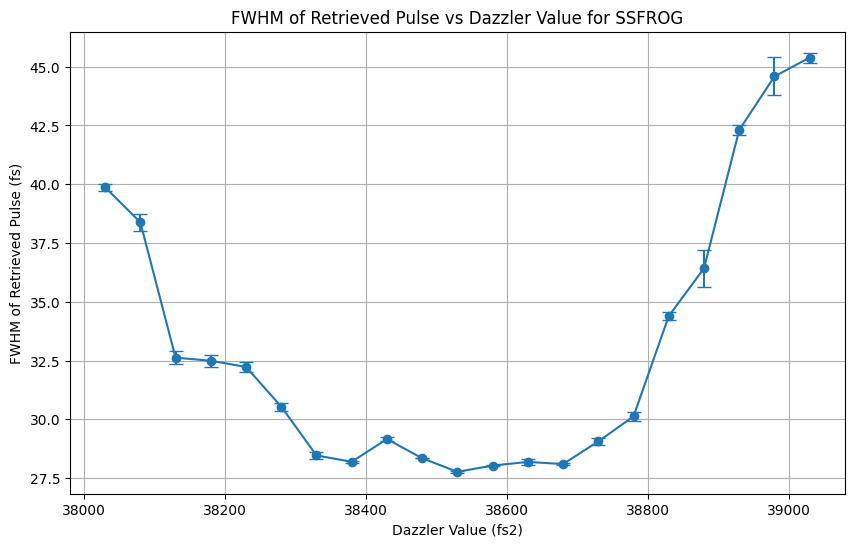

In [23]:
#plot FWHM of the retrieved pulse as a function of the dazzler value, using the results saved in the npz files.
#plot average FWHM with error bars

dazzler_values_ssfrog = []
fwhm_ssfrog_avg=[]
fwhm_ssfrog_std=[]
for dazzler_value in range(38030, 39030 + 1, 50):
    fwhm_array=[]
    for i in range(1, n_files + 1):
        npz_file = os.path.join(r"D:\FROG_RT_Xuyang\results\SSFROG\calibration", f"scanning_frog_{dazzler_value}_{i}.npz")
        if not os.path.exists(npz_file):
            print(f"No result file found for dazzler value: {dazzler_value}, file number: {i}")
            continue
        data = np.load(npz_file, allow_pickle=True)
        result = data["result"].item()
        fwhm = result["FWHMt"]
        fwhm_array.append(fwhm)
    if len(fwhm_array) > 0:
        dazzler_values_ssfrog.append(dazzler_value)
        fwhm_ssfrog_avg.append(np.mean(fwhm_array))
        fwhm_ssfrog_std.append(np.std(fwhm_array))

plt.figure(figsize=(10, 6))
plt.errorbar(dazzler_values_ssfrog, fwhm_ssfrog_avg, yerr=fwhm_ssfrog_std, marker='o', capsize=5)
plt.title("FWHM of Retrieved Pulse vs Dazzler Value for SSFROG")
plt.xlabel("Dazzler Value (fs2)")
plt.ylabel("FWHM of Retrieved Pulse (fs)")
plt.grid()
plt.savefig(r"D:\FROG_RT_Xuyang\results\SSFROG\calibration\fwhm_vs_dazzler_value.png")
plt.show()